In [1]:
# -----------------------------
# 1️ Import des bibliothèques
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pour sauvegarder le modèle tabulaire
import joblib

In [3]:
# -----------------------------
# 2️⃣ Charger le dataset
# -----------------------------
df = pd.read_csv("dataset_multimodal.csv")

# Garder seulement ce qu'on utilise pour le CNN
df = df[['image_path', 'cancer_image', 'proba_faible', 'proba_intermediaire', 'proba_eleve']]

# Vérifier
df.head()

,image_path,cancer_image,proba_faible,proba_intermediaire,proba_eleve
0,jsrt_subset/malin/JPCLN001.jpg,1,4.439349e-07,0.000003,0.999996
1,jsrt_subset/benin/JPCLN002.jpg,0,4.663972e-06,0.999962,0.000034
2,jsrt_subset/malin/JPCLN003.jpg,1,5.867294e-07,0.000010,0.999990
3,jsrt_subset/benin/JPCLN004.jpg,0,3.876222e-06,0.999977,0.000019
4,jsrt_subset/malin/JPCLN005.jpg,1,5.625352e-07,0.000010,0.999990


In [4]:
# -----------------------------
# 3️⃣ Préparer les images
# -----------------------------
IMG_SIZE = (224, 224)  # Taille standard

def load_and_preprocess(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE, color_mode="grayscale")
    img = tf.keras.utils.img_to_array(img)
    img = img / 255.0  # normalisation
    return img

# Charger toutes les images
images = np.array([load_and_preprocess(p) for p in df['image_path']])
labels = np.array(df['cancer_image'])

# Ajouter la dimension canal pour CNN
images = images.reshape(-1, 224, 224, 1)

In [5]:
# -----------------------------
# 4️⃣ Séparer train/test
# -----------------------------
X_train_img, X_test_img, y_train, y_test, train_tab, test_tab = train_test_split(
    images, labels, df[['proba_faible', 'proba_intermediaire', 'proba_eleve']].values,
    test_size=0.2, random_state=42, stratify=labels
)

In [6]:
# -----------------------------
# 5️⃣ Data augmentation
# -----------------------------
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_img)

In [7]:
# -----------------------------
# 6️⃣ Modèle CNN sur image seule
# -----------------------------
input_img = Input(shape=(224,224,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output_img = Dense(1, activation='sigmoid')(x)

cnn_model = Model(inputs=input_img, outputs=output_img)
cnn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,515,329 (24.85 MB)

 Trainable params: 6,515,329 (24.85 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# -----------------------------
# 7️⃣ Entraîner le modèle CNN image seule
# -----------------------------
history_img = cnn_model.fit(
    datagen.flow(X_train_img, y_train, batch_size=8),
    validation_data=(X_test_img, y_test),
    epochs=20
)

Epoch 1/20


c:\Users\airac\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 337ms/step - accuracy: 0.4330 - loss: 1.3733 - val_accuracy: 0.5405 - val_loss: 0.6896
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.5573 - loss: 0.6930 - val_accuracy: 0.5405 - val_loss: 0.6897
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 279ms/step - accuracy: 0.5176 - loss: 0.6880 - val_accuracy: 0.5405 - val_loss: 0.6919
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.5178 - loss: 0.6929 - val_accuracy: 0.5405 - val_loss: 0.6936
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 313ms/step - accuracy: 0.5196 - loss: 0.7025 - val_accuracy: 0.5405 - val_loss: 0.6902
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - accuracy: 0.5565 - loss: 0.6883 - val_accuracy: 0.5405 - val_loss: 0.6902
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.4348 - loss: 0.7007 - val_accuracy: 0.5405 - val_loss: 0.6897
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 274ms/step - accuracy: 0.5318 - loss: 0.6914 - val_accuracy: 0.5405 - val_

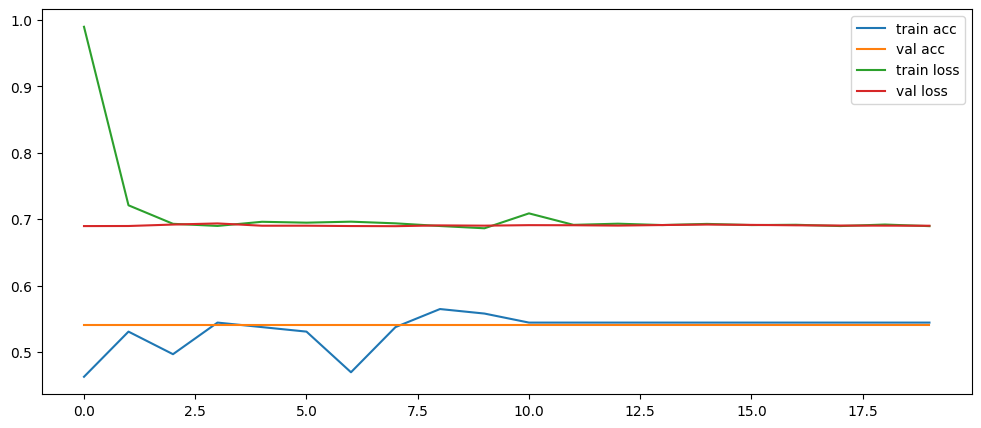

In [9]:
# -----------------------------
# 8️⃣ Courbes d’apprentissage
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(history_img.history['accuracy'], label='train acc')
plt.plot(history_img.history['val_accuracy'], label='val acc')
plt.plot(history_img.history['loss'], label='train loss')
plt.plot(history_img.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [10]:
# -----------------------------
# 9️⃣ Fusion multimodale (image + tabulaire)
# -----------------------------
# Input image
input_img2 = Input(shape=(224,224,1))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img2)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)

# Input tabulaire
input_tab = Input(shape=(3,))
y = Dense(16, activation='relu')(input_tab)

# Fusion
combined = concatenate([x, y])
z = Dense(32, activation='relu')(combined)
z = Dropout(0.5)(z)
output_combined = Dense(1, activation='sigmoid')(z)

multimodal_model = Model(inputs=[input_img2, input_tab], outputs=output_combined)
multimodal_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
multimodal_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 100352)    │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │  6,422,592 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         64 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,517,953 (24.86 MB)

 Trainable params: 6,517,953 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# -----------------------------
# 10️⃣ Entraîner le modèle multimodal
# -----------------------------
history_multi = multimodal_model.fit(
    [X_train_img, train_tab], y_train,
    validation_data=([X_test_img, test_tab], y_test),
    epochs=20,
    batch_size=8
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.5051 - loss: 0.7698 - val_accuracy: 0.5405 - val_loss: 0.6432
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.6364 - loss: 0.6329 - val_accuracy: 0.5405 - val_loss: 0.6118
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - accuracy: 0.6570 - loss: 0.6019 - val_accuracy: 0.7838 - val_loss: 0.5843
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.8202 - loss: 0.5758 - val_accuracy: 0.7838 - val_loss: 0.5416
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 270ms/step - accuracy: 0.8609 - loss: 0.5160 - val_accuracy: 0.8108 - val_loss: 0.4926
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step - accuracy: 0.9554 - loss: 0.4517 - val_accuracy: 0.7568 - val_loss: 0.4628
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.8679 - loss: 0.3952 - val_accuracy: 0.8919 - val_loss: 0.3732
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 335ms/step - accuracy: 0.9791 - loss: 0.3109 - val_accuracy: 0.

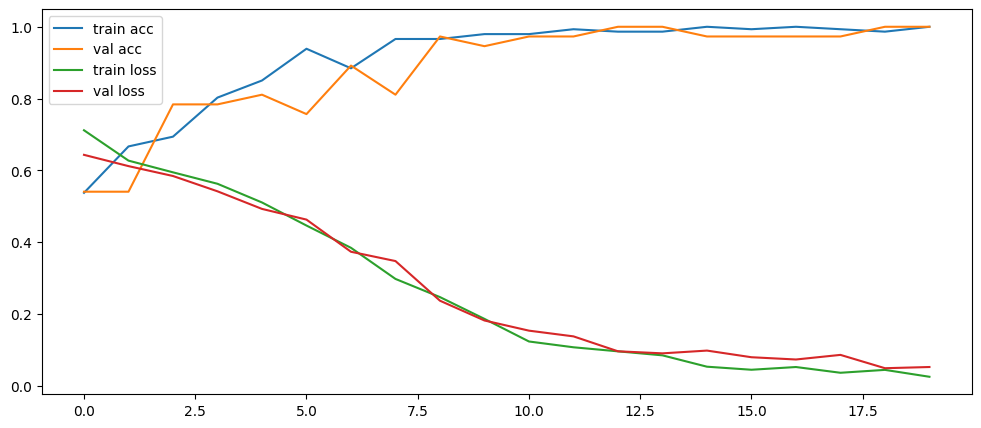

In [12]:
# -----------------------------
# 11️⃣ Courbes d’apprentissage du modèle multimodal
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(history_multi.history['accuracy'], label='train acc')
plt.plot(history_multi.history['val_accuracy'], label='val acc')
plt.plot(history_multi.history['loss'], label='train loss')
plt.plot(history_multi.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [13]:
# -----------------------------
# 12️⃣ Sauvegarder les modèles
# -----------------------------
cnn_model.save("cnn_image_model.h5")
multimodal_model.save("cnn_multimodal_model.h5")

In [14]:
IMG_SIZE = (224,224)

def preprocess_image(img_path):

    img = tf.keras.utils.load_img(
        img_path,
        target_size=IMG_SIZE,
        color_mode="grayscale"
    )

    img = tf.keras.utils.img_to_array(img)

    img = img / 255.0

    img = img.reshape(1,224,224,1)

    return img

In [19]:
model = tf.keras.models.load_model("cnn_image_model.h5")
print("Modèle chargé avec succès")

Modèle chargé avec succès


In [20]:
def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224,224), color_mode="grayscale")
    img = tf.keras.utils.img_to_array(img)
    img = img / 255.0
    img = img.reshape(1,224,224,1)
    return img

image_path = "jsrt_subset/malin/JPCLN001.jpg"
image = preprocess_image(image_path)

In [21]:
prediction = model.predict(image)
print("Probabilité cancer :", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Résultat : Cancer détecté")
else:
    print("Résultat : Pas de cancer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Probabilité cancer : 0.52692205
Résultat : Cancer détecté
